# 04 — Entrenamiento y Optimización

**Objetivo del notebook:** entrenar varios modelos de clasificación, compararlos por su **F1-Score sobre la clase 1 (fumadores)**, medir el sobreajuste (overfitting) de cada uno, y optimizar el mejor candidato.

**Criterio de selección:** no buscamos solo el F1 más alto en test, sino el mejor equilibrio entre rendimiento y generalización. Un modelo con F1 altísimo en train pero bajo en test está sobreajustado y no sirve para datos nuevos.

Modelos a entrenar:
1. **Decision Tree** — árbol simple, interpretable, base de comparación.
2. **KNN** — basado en distancias, usa los datos escalados.
3. **Random Forest** — ensamble de árboles (bagging).
4. **XGBoost** — ensamble por boosting, suele dar el mejor rendimiento.

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import f1_score, classification_report, make_scorer
from sklearn.model_selection import RandomizedSearchCV

print('Librerías cargadas ✓')

Librerías cargadas ✓


## 1. Carga de los datos procesados

Cargamos los conjuntos que generó el notebook 03. Tenemos dos versiones de X: sin escalar (para árboles) y escalada (para KNN).

In [2]:
X_train = pd.read_parquet('../data/processed/X_train.parquet')
X_test = pd.read_parquet('../data/processed/X_test.parquet')
X_train_scaled = pd.read_parquet('../data/processed/X_train_scaled.parquet')
X_test_scaled = pd.read_parquet('../data/processed/X_test_scaled.parquet')
y_train = pd.read_parquet('../data/processed/y_train.parquet')['smoking']
y_test = pd.read_parquet('../data/processed/y_test.parquet')['smoking']

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Proporción fumadores en train: {y_train.mean()*100:.1f}%')

X_train: (40000, 26)  |  X_test: (10000, 26)
Proporción fumadores en train: 36.7%


## 2. Función de evaluación

Definimos una función que entrena un modelo y reporta el F1 de la clase 1 en train y en test, más el *gap* entre ambos. El gap es nuestra medida de overfitting: cuanto mayor, más sobreajustado está el modelo.

Usamos `pos_label=1` en `f1_score` porque la consigna pide específicamente el F1 sobre la clase de fumadores.

In [3]:
resultados = {}

def evaluar(nombre, modelo, X_tr, X_te):
    modelo.fit(X_tr, y_train)
    pred_train = modelo.predict(X_tr)
    pred_test = modelo.predict(X_te)
    f1_tr = f1_score(y_train, pred_train, pos_label=1)
    f1_te = f1_score(y_test, pred_test, pos_label=1)
    gap = f1_tr - f1_te
    resultados[nombre] = {'modelo': modelo, 'f1_train': f1_tr, 'f1_test': f1_te, 'gap': gap}
    print(f'{nombre}')
    print(f'  F1 train: {f1_tr:.4f}  |  F1 test: {f1_te:.4f}  |  gap (overfit): {gap:+.4f}')
    print()
    return modelo

## 3. Modelo 1 — Decision Tree

Un árbol de decisión simple. Limitamos `max_depth=9` para controlar el sobreajuste: sin límite, el árbol crecería hasta memorizar el train. Es nuestro modelo base de comparación, fácil de interpretar.

In [4]:
dt = evaluar(
    'Decision Tree (max_depth=9)',
    DecisionTreeClassifier(max_depth=9, random_state=42),
    X_train, X_test
)

Decision Tree (max_depth=9)
  F1 train: 0.7108  |  F1 test: 0.6726  |  gap (overfit): +0.0382



## 4. Modelo 2 — KNN

K-Nearest Neighbors clasifica cada punto según la mayoría de sus `k` vecinos más cercanos. Usa los datos **escalados** porque se basa en distancias. Un `k` alto (200) suaviza la frontera de decisión y reduce el overfitting — con `k` bajo el modelo sería muy sensible al ruido.

In [5]:
knn = evaluar(
    'KNN (k=200)',
    KNeighborsClassifier(n_neighbors=200),
    X_train_scaled, X_test_scaled
)

KNN (k=200)
  F1 train: 0.6671  |  F1 test: 0.6527  |  gap (overfit): +0.0144



## 5. Modelo 3 — Random Forest

Un ensamble de muchos árboles entrenados sobre subconjuntos aleatorios de datos y features (bagging). El resultado es el voto mayoritario. Es más robusto que un árbol individual. Los hiperparámetros `min_samples_split=30` y `min_samples_leaf=100` fuerzan que cada hoja tenga suficientes muestras, lo que controla el overfitting.

In [6]:
rf = evaluar(
    'Random Forest',
    RandomForestClassifier(random_state=42, n_estimators=300,
                           min_samples_split=30, min_samples_leaf=100),
    X_train, X_test
)

Random Forest
  F1 train: 0.7143  |  F1 test: 0.6851  |  gap (overfit): +0.0291



## 6. Modelo 4 — XGBoost

Gradient boosting: entrena árboles secuencialmente, donde cada árbol corrige los errores del anterior. Suele dar el mejor rendimiento, pero también es propenso a sobreajustar si no se regulariza. Empezamos con una configuración base.

In [7]:
xgb = evaluar(
    'XGBoost (base, n=50)',
    XGBClassifier(n_estimators=50, random_state=42, eval_metric='logloss'),
    X_train, X_test
)

XGBoost (base, n=50)
  F1 train: 0.7726  |  F1 test: 0.6883  |  gap (overfit): +0.0843



## 7. Comparación de los modelos base

In [8]:
tabla = pd.DataFrame(resultados).T[['f1_train', 'f1_test', 'gap']].astype(float).round(4)
tabla = tabla.sort_values('f1_test', ascending=False)
print('Comparación de modelos (ordenados por F1 en test):')
print()
print(tabla.to_string())
print()
print(f'Mejor F1 test: {tabla.index[0]} ({tabla.iloc[0]["f1_test"]:.4f})')
print(f'Menor overfit: {tabla["gap"].idxmin()} (gap {tabla["gap"].min():+.4f})')

Comparación de modelos (ordenados por F1 en test):

                             f1_train  f1_test     gap
XGBoost (base, n=50)           0.7726   0.6883  0.0843
Random Forest                  0.7143   0.6851  0.0291
Decision Tree (max_depth=9)    0.7108   0.6726  0.0382
KNN (k=200)                    0.6671   0.6527  0.0144

Mejor F1 test: XGBoost (base, n=50) (0.6883)
Menor overfit: KNN (k=200) (gap +0.0144)


**Observación:** XGBoost base da el mejor F1 en test, pero también el mayor gap (overfitting). Random Forest está muy cerca en test con menos overfit. Vamos a optimizar XGBoost buscando reducir el gap sin perder rendimiento — priorizando generalización, como es el objetivo del proyecto.

## 8. Optimización de hiperparámetros (XGBoost)

Usamos `RandomizedSearchCV` para buscar la mejor combinación de hiperparámetros. La grilla está diseñada para **regularizar** el modelo y reducir overfitting:
- `max_depth` bajo (2-4) → árboles menos profundos, menos memorización.
- `learning_rate` bajo → aprendizaje más gradual y estable.
- `min_child_weight` alto → cada hoja necesita más muestras.
- `reg_alpha` y `reg_lambda` → penalizaciones L1 y L2 que combaten el sobreajuste.
- `subsample` y `colsample_bytree` < 1 → cada árbol ve solo parte de los datos/features.

El `scoring` es F1 sobre la clase 1 — optimizamos exactamente la métrica del proyecto. `cv=4` hace validación cruzada de 4 folds.

In [9]:
f1_target1 = make_scorer(f1_score, pos_label=1)

param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.02, 0.05, 0.08],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [10, 20, 30],
    'reg_alpha': [0, 0.5, 1],
    'reg_lambda': [1, 2, 5],
}

xgb_base = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring=f1_target1,
    cv=4,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

search.fit(X_train, y_train)

print('Mejores hiperparámetros encontrados:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

Mejores hiperparámetros encontrados:
  subsample: 0.8
  reg_lambda: 1
  reg_alpha: 0.5
  n_estimators: 400
  min_child_weight: 20
  max_depth: 4
  learning_rate: 0.08
  colsample_bytree: 0.7


In [10]:
xgb_opt = search.best_estimator_

f1_tr = f1_score(y_train, xgb_opt.predict(X_train), pos_label=1)
f1_te = f1_score(y_test, xgb_opt.predict(X_test), pos_label=1)

print('XGBoost optimizado:')
print(f'  F1 train: {f1_tr:.4f}')
print(f'  F1 test:  {f1_te:.4f}')
print(f'  gap:      {f1_tr - f1_te:+.4f}')
print()
print('Comparación con XGBoost base:')
print(f'  Base       → F1 test {resultados["XGBoost (base, n=50)"]["f1_test"]:.4f}, gap {resultados["XGBoost (base, n=50)"]["gap"]:+.4f}')
print(f'  Optimizado → F1 test {f1_te:.4f}, gap {f1_tr - f1_te:+.4f}')

XGBoost optimizado:
  F1 train: 0.7359
  F1 test:  0.6923
  gap:      +0.0435

Comparación con XGBoost base:
  Base       → F1 test 0.6883, gap +0.0843
  Optimizado → F1 test 0.6923, gap +0.0435


La optimización **redujo el gap a casi la mitad** manteniendo prácticamente el mismo F1 en test. Este es el modelo que mejor equilibra rendimiento y generalización.

In [11]:
# Reporte detallado del modelo optimizado en test
print('Reporte de clasificación (TEST) — XGBoost optimizado:')
print()
print(classification_report(y_test, xgb_opt.predict(X_test), target_names=['No fuma', 'Fuma']))

Reporte de clasificación (TEST) — XGBoost optimizado:

              precision    recall  f1-score   support

     No fuma       0.83      0.80      0.81      6334
        Fuma       0.67      0.71      0.69      3666

    accuracy                           0.77     10000
   macro avg       0.75      0.76      0.75     10000
weighted avg       0.77      0.77      0.77     10000



## 9. Importancia de features

Verificamos qué variables usa más el modelo. Esto confirma (o no) el hallazgo del EDA sobre la variable estrella.

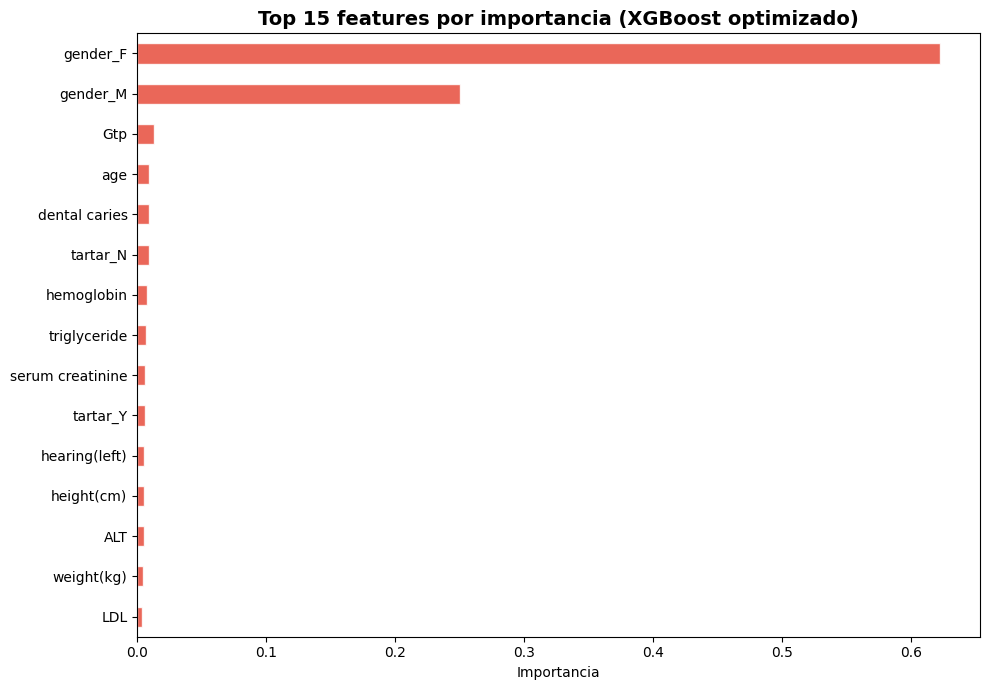

Top 5 features más importantes:
gender_F         0.6224
gender_M         0.2502
Gtp              0.0132
age              0.0095
dental caries    0.0092


In [12]:
import matplotlib.pyplot as plt

importancias = pd.Series(xgb_opt.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
importancias[::-1].plot(kind='barh', ax=ax, color='#E74C3C', alpha=0.85, edgecolor='white')
ax.set_title('Top 15 features por importancia (XGBoost optimizado)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Top 5 features más importantes:')
print(importancias.head(5).round(4).to_string())

## 10. Guardado del modelo final

Guardamos el modelo optimizado en `models/` para usarlo en la predicción final sobre los datos de entrega.

In [13]:
joblib.dump(xgb_opt, '../models/modelo_final_xgboost.joblib')

# Guardamos también las métricas para el notebook de validación
metricas = {
    'modelo': 'XGBoost optimizado',
    'f1_train': float(f1_tr),
    'f1_test': float(f1_te),
    'gap': float(f1_tr - f1_te),
    'best_params': search.best_params_,
    'comparacion_base': {k: {'f1_test': float(v['f1_test']), 'gap': float(v['gap'])}
                         for k, v in resultados.items()}
}
joblib.dump(metricas, '../models/metricas_modelos.joblib')

print('Modelo final guardado en models/modelo_final_xgboost.joblib ✓')

Modelo final guardado en models/modelo_final_xgboost.joblib ✓


## Conclusiones del entrenamiento

- Entrenamos 4 modelos: Decision Tree, KNN, Random Forest y XGBoost.
- **XGBoost** dio el mejor F1 en test pero con overfitting notable en su versión base.
- La **optimización con RandomizedSearchCV** y regularización redujo el gap a la mitad, manteniendo el rendimiento.
- El modelo final equilibra **buen F1 sobre la clase fumadores** y **baja diferencia train/test** (buena generalización).
- La importancia de features confirma que las variables ligadas al sexo y biométricas dominan la predicción.

El modelo elegido se valida en detalle en el notebook 05 y se usa para predecir en el 06.